# Logistic Regression Binary Classification

Logistic regression is a fundamental machine learning method originally from the field of statistics. It's a great choice for generating a baseline for any binary classification problem (meaning there are only two outcomes). This template trains and evaluates a logistic regression model for a **binary classification** problem. If you would like to learn more about logistic regression, take a look at DataCamp's [Linear Classifiers in Python](https://app.datacamp.com/learn/courses/linear-classifiers-in-python) course.

The placeholder dataset in this template consists of churn data from a telecom company. Each row represents a customer over a year and whether the customer churned (the target variable; `1` = yes, `0` = no). You can find more information on this dataset's source and dictionary [here](https://app.datacamp.com/workspace/datasets/dataset-python-telecom-customer-churn).

## 1. Dataset Exploration

In [2]:
# Load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    RocCurveDisplay,
    f1_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [3]:
# read in the csv file on customer churn
df = pd.read_csv('customer_churn.csv')
print(df.sample(5).T)

                         2504  2280  1076   1320  2215
Call  Failure               6     9     4      7     5
Complains                   0     0     0      0     0
Subscription  Length       37    39    33     41    37
Charge  Amount              1     3     0      1     1
Seconds of Use           2518  7170  2685  11420  6745
Frequency of SMS            7    31     2     19   188
Distinct Called Numbers    30    28    14     51    26
Age                        25    55    25     45    30
Churn                       0     0     1      0     0


In [4]:
# check if there are any null values
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Call  Failure            3150 non-null   int64
 1   Complains                3150 non-null   int64
 2   Subscription  Length     3150 non-null   int64
 3   Charge  Amount           3150 non-null   int64
 4   Seconds of Use           3150 non-null   int64
 5   Frequency of SMS         3150 non-null   int64
 6   Distinct Called Numbers  3150 non-null   int64
 7   Age                      3150 non-null   int64
 8   Churn                    3150 non-null   int64
dtypes: int64(9)
memory usage: 221.6 KB
None
Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of SMS           0
Distinct Called Numbers    0
Age                        0
Churn                      0
dtype: int64


NB.: Better give columns abbreviations, since they have spaces and capitals

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

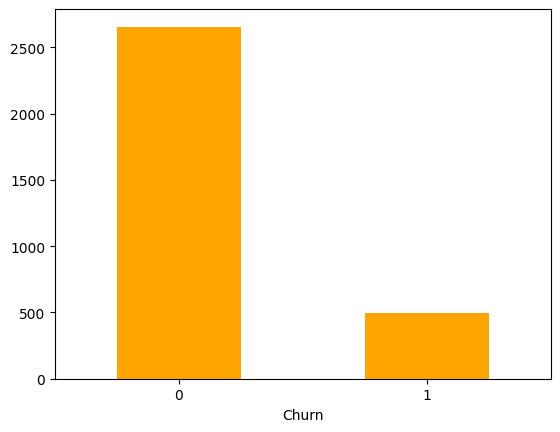

In [ ]:
df["Churn"].value_counts().plot(kind = "bar", color="orange")
plt.xticks(rotation=0)

Text(0.5, 1.0, 'Target distribution: Churned?')

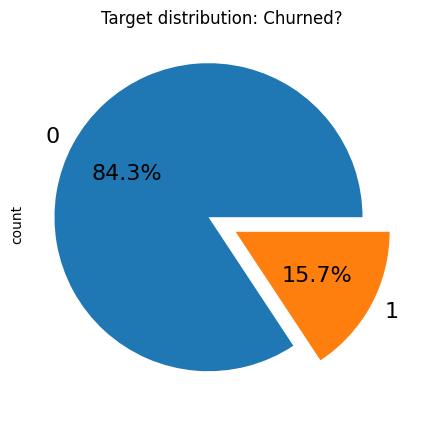

In [ ]:
plt.figure(figsize=(5,5))
df["Churn"].value_counts().plot.pie(explode=[0.1,0.1], autopct='%1.1f%%', textprops={'fontsize':16}).set_title("Target distribution: Churned?")


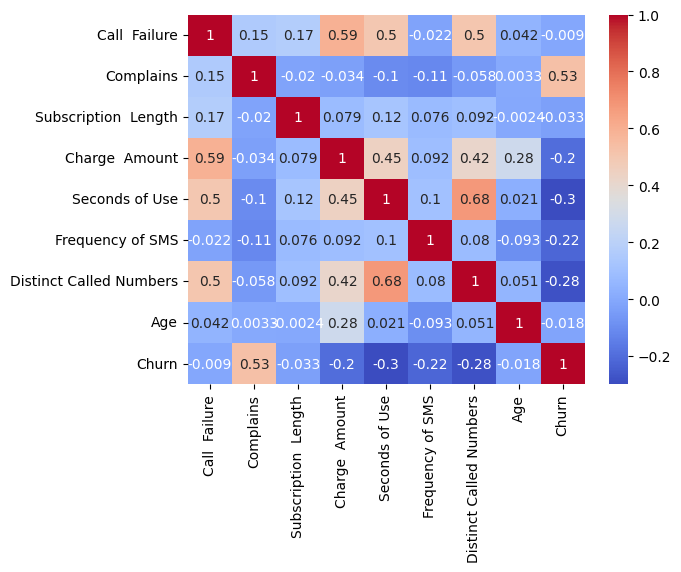

In [7]:
sns.heatmap(df.corr(numeric_only =True), cmap = "coolwarm", annot =True)
plt.show()

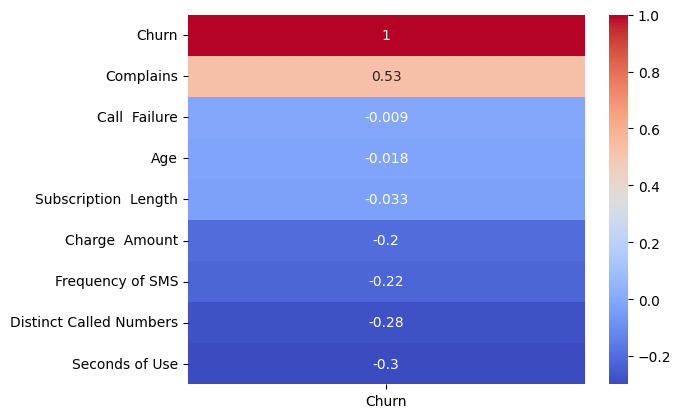

In [8]:
sns.heatmap(df.corr()["Churn"].sort_values(ascending=False).to_frame(), cmap = "coolwarm", annot =True)
plt.show()
# most significant are closest to 1 (positive correlation) and -1 (negative correlation). the least significant are close to 0 (no correlation)

Crosstab of Complains vs Churn:
Churn         0    1   All
Complains                 
0          2614  295  2909
1            41  200   241
All        2655  495  3150

Percentage distribution within each complains category:
Churn          0      1
Complains              
0          89.86  10.14
1          17.01  82.99



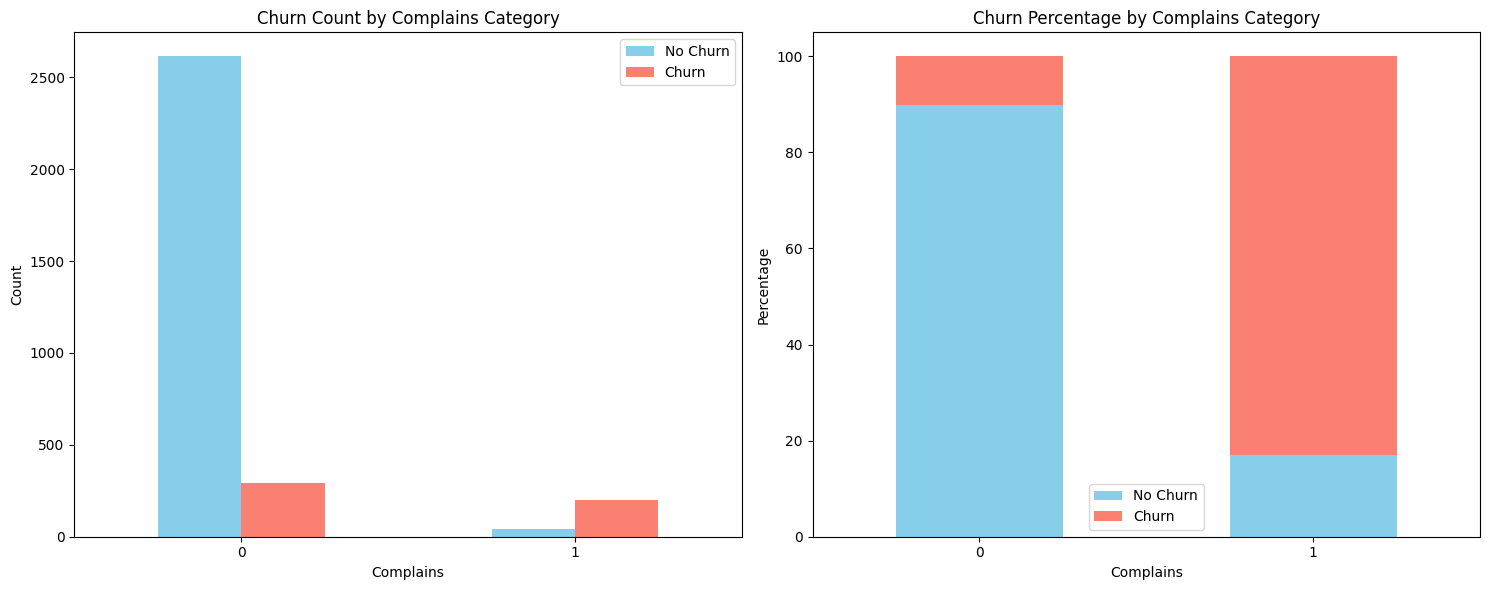

In [ ]:
# Create a crosstab of complains vs churn
complains_churn_crosstab = pd.crosstab(df['Complains'], df['Churn'], margins=True)
print("Crosstab of Complains vs Churn:")
print(complains_churn_crosstab)
print()

# Calculate percentages
complains_churn_pct = pd.crosstab(df['Complains'], df['Churn'], normalize='index') * 100
print("Percentage distribution within each complains category:")
print(complains_churn_pct.round(2))
print()

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot showing counts
complains_churn_crosstab.iloc[:-1, :-1].plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('Churn Count by Complains')
ax1.set_xlabel('Complains')
ax1.set_ylabel('Count')
ax1.legend(['No Churn', 'Churn'])
ax1.tick_params(axis='x', rotation=0)

# Stacked percentage bar plot
complains_churn_pct.plot(kind='bar', stacked=True, ax=ax2, color=['skyblue', 'salmon'])
ax2.set_title('Churn Percentage by Complains')
ax2.set_xlabel('Complains')
ax2.set_ylabel('Percentage')
ax2.legend(['No Churn', 'Churn'])
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2. Splitting and standardizing the data

To split the data, we'll use the [train_test_split()]( https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html ) function. Then, we'll standardize the input data using [`StandardScaler()`]( https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler ) (note: this should be done after splitting the data to avoid data leakage). To learn more about standardizing data and preprocessing techniques, visit DataCamp's [Preprocessing for Machine Learning in Python](https://app.datacamp.com/learn/courses/preprocessing-for-machine-learning-in-python).

In [ ]:
# Split the data into two DataFrames: X (features) and y (target variable)
X = df.iloc[:, :8] # Specify at least one column as a feature (begin with all, next iter pick/adjust certain features, bv. df[["Complains", "Seconds of Use"]])
y = df["Churn"] # Specify one column as the target variable

# Split the data into train and test subsets
# You can adjust the test size and random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123
)

In [11]:
print(f"Y_TRAIN: {y_train.value_counts(normalize=True)}")
print(f"Y_TEST: {y_test.value_counts(normalize=True)}")

Y_TRAIN: Churn
0    0.84127
1    0.15873
Name: proportion, dtype: float64
Y_TEST: Churn
0    0.846561
1    0.153439
Name: proportion, dtype: float64


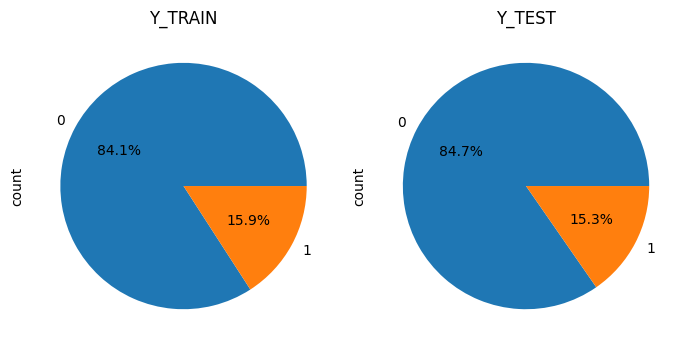

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))

y_train.value_counts().plot.pie(autopct='%1.1f%%', ax=ax1).set_title("Y_TRAIN")
y_test.value_counts().plot.pie(autopct='%1.1f%%', ax=ax2).set_title("Y_TEST")
plt.tight_layout()

(array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(1, 0, 'Call  Failure'),
  Text(2, 0, 'Complains'),
  Text(3, 0, 'Subscription  Length'),
  Text(4, 0, 'Charge  Amount'),
  Text(5, 0, 'Seconds of Use'),
  Text(6, 0, 'Frequency of SMS'),
  Text(7, 0, 'Distinct Called Numbers'),
  Text(8, 0, 'Age'),
  Text(9, 0, 'Churn')])

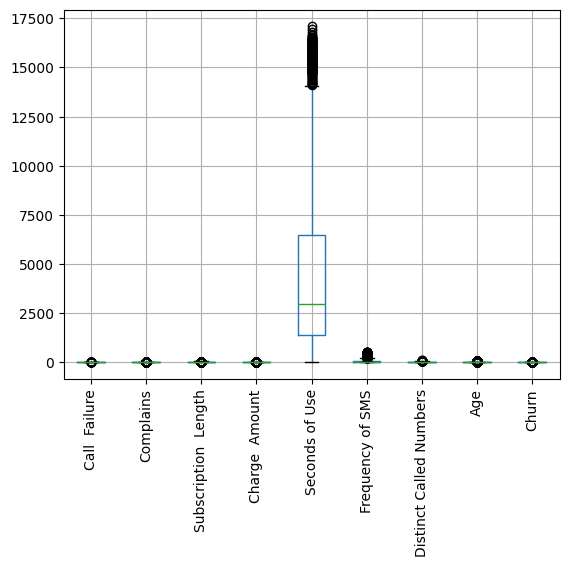

In [13]:
# boxplot shows whether standartization is needed: here seconds of use is very diff in scale from the rest:
df.boxplot()
plt.xticks(rotation=90)

(array([1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(1, 0, 'Call  Failure'),
  Text(2, 0, 'Complains'),
  Text(3, 0, 'Subscription  Length'),
  Text(4, 0, 'Charge  Amount'),
  Text(5, 0, 'Seconds of Use'),
  Text(6, 0, 'Frequency of SMS'),
  Text(7, 0, 'Distinct Called Numbers'),
  Text(8, 0, 'Age')])

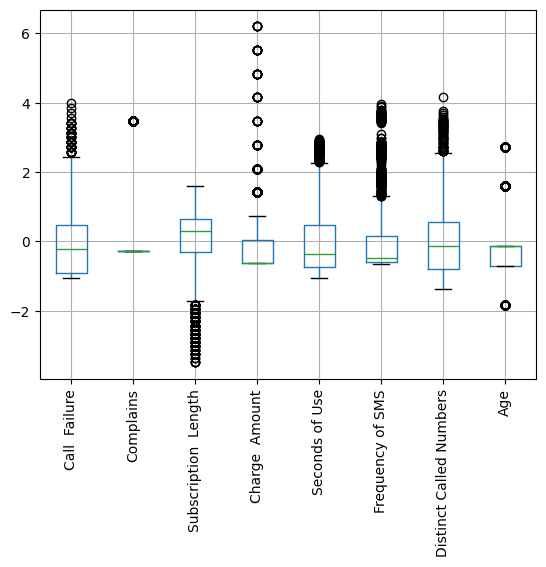

In [14]:
sc = StandardScaler().fit(X_train)
X_train_scaled = sc.transform(X_train) # can be done later for X_test
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled.boxplot()
plt.xticks(rotation=90)
# we see that data is not normally distributed (has to pass by log or other transformations first),
# but the 4th var is now comparable in scale

In [15]:
X_test_scaled = sc.transform(X_test)

## 3. Building a logistic Classifier

In [ ]:
# Define parameters: these will need to be tuned to prevent overfitting and underfitting
params = {
    "penalty": "l2",  # Depricated, use L1_ratio: 1 = 'l1', 0 = 'l2', 0<x<1 =  both ('elasticnet')
    "C": 1,  # Inverse of regularization strength, a positive float
    "random_state": 123,
}
# NB. if given higher penalty for complexity, recall becomes lower

# Create a logistic regression classifier object with the parameters above
clf = LogisticRegression(**params)

# Train the classifier
clf = clf.fit(X_train_scaled, y_train)

# estimate by comparison the performance on train and test data
y_train_pred = clf.predict(X_train_scaled)
y_pred = clf.predict(X_test_scaled)


C:\Users\Cursist\DataScienceCourse\DS_DataStuff\ML_Basics\ML_Projects\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Cursist\DataScienceCourse\DS_DataStuff\ML_Basics\ML_Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [30]:
# training set:
cnf_matrix_logreg_model_train = confusion_matrix(y_train, y_train_pred)
print(f"Train set CM:\n{cnf_matrix_logreg_model_train}")
print("Precision (% of correctly predicted of all churners predictions)", precision_score(y_train,y_train_pred))
print("Recall (% of real churners classified als churners)",recall_score(y_train, y_train_pred))
# test set:
cnf_matrix_logreg_model_test = confusion_matrix(y_test, y_pred)
print(f"Test set CM:\n{cnf_matrix_logreg_model_test}")
print("Precision (% of correctly predicted of all churners predictions)", precision_score(y_test,y_pred))
print("Recall (% of real churners classified als churners)",recall_score(y_test, y_pred))

# NB1.: CM is turned upside down FN - FP/FP - TP (see plot below)!!!
# NB.: we're not interested in accuracy (corr predictions of non-churners)

Train set CM:
[[1831   24]
 [ 197  153]]
Precision (% of correctly predicted of all churners predictions) 0.864406779661017
Recall (% of real churners classified als churners) 0.43714285714285717
Test set CM:
[[789  11]
 [ 77  68]]
Precision (% of correctly predicted of all churners predictions) 0.8607594936708861
Recall (% of real churners classified als churners) 0.4689655172413793


Text(0.5, 23.52222222222222, 'Predicted label')

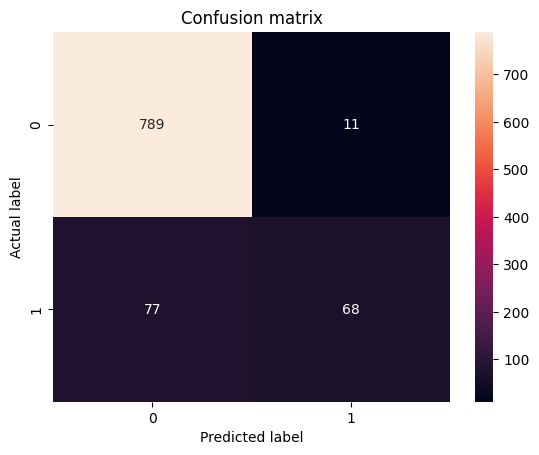

In [36]:
# Plot a labeled confusion matrix with Seaborn
sns.heatmap(cnf_matrix_logreg_model_test, annot=True, fmt="g")
plt.title("Confusion matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")

In [19]:
# combined score:
print(f'F1-score is: {100*f1_score(y_test, y_pred):.2f}')
# pos_label: what is your class of interest
# if you give parameter average='weighted' means both evenly, which is not our case

F1-score is: 60.71


In [20]:
# manuele berekening van F1 score: 2xTP/(2xTP + FP + FN)
2*68/(2*68+11+77)

0.6071428571428571

C:\Users\Cursist\DataScienceCourse\DS_DataStuff\ML_Basics\ML_Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


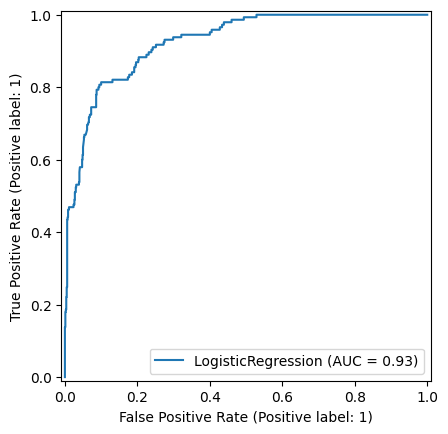

In [ ]:
# Plot ROC (AUC) curve (trade-off between Precision and Recall)
RocCurveDisplay.from_estimator(clf, X_test_scaled, y_test)

# decision treshold value (def= 0.5 or 50%) defines the border for classification (what seen as churner can be lowered to 30%, for ex.)
# also with the class_weight param
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [22]:
# Get the model coefficients and intercept
print("Model Coefficients (with feature names):")
feature_names = ['Call Failure', 'Complains', 'Subscription Length', 'Charge Amount', 
                 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers']

for i, (feature, coef) in enumerate(zip(feature_names, clf.coef_[0])):
    print(f"{feature}: {coef:.6f}")

print(f"\nIntercept: {clf.intercept_[0]:.6f}")

Model Coefficients (with feature names):
Call Failure: 0.648959
Complains: 1.096769
Subscription Length: -0.075492
Charge Amount: -0.762199
Seconds of Use: -1.413594
Frequency of use: -1.385958
Frequency of SMS: -0.671927
Distinct Called Numbers: -0.007371

Intercept: -3.339455


In [23]:
# dit code werkt niet (geeft error)

import statsmodels.api as sm

# Add constant for intercept
X_train_with_const = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_with_const)
result = logit_model.fit()
print(result.summary())

ValueError: The indices for endog and exog are not aligned